<a href="https://colab.research.google.com/github/python4recursion/bookcode/blob/main/CH03/3_sudoku.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# CH03: sudoku.py
import random
class Sudoku:
    def __init__(self, filename, dim = 1, debug = False):
        self.filename = filename
        self.dim = dim
        self.debug = debug
        self.cells = [[0 for c in range(9)] for r in range(9)]
        self.filled = 0
        # a list of numbers 1, 2, ..., 9
        allow = [val for val in range(1, 10)]
        # each cell has a list of allowed values
        self.allow = [[allow.copy() for c in range(9)] for r in range(9)]
        self.read(filename)

    def read(self, filename):
        fhd = open(filename, 'r')
        alllines = fhd.readlines()
        numlines = len(alllines)
        # skip the first line because the first line stores
        # the format: quizzes,solutions
        whichline = random.randint(1, numlines - 1)  # select one puzzle
        if (self.debug):
            print('whichline:', whichline)
        # the first 81 characters are the quiz
        line = alllines[whichline][0:81]
        # the 82nd (index is 81) character is a comma
        # the next 81 characters are the solution
        self.solution = alllines[whichline][82:163]
        if (self.debug):
            print(f'solution = {self.solution}')
            print(f'line = {line}')
        index = 0
        for row in range(9):
            for col in range(9):
                val = int(line[index])
                index += 1
                if (val != 0):  # 0 means unfilled
                    self.cells[row][col] = val
                    self.filled += 1
                    self.removeUsed(row, col, val)
        if (self.debug):
            self.printCells()
            print('***********')
            print('Allowed')
            self.printAllow()

    def removeUsed(self, row, col, val):
        # cell[row][col] is val
        self.allow[row][col] = [val]  # will be removed later
        # remove val from the same row
        for c in range(9):
            if (val in self.allow[row][c]):
                self.allow[row][c].remove(val)
        # remove val from the same column
        for r in range(9):
            if (val in self.allow[r][col]):
                self.allow[r][col].remove(val)
        # remove val from the same 3x3 square
        rowstart = int(row / 3) * 3
        colstart = int(col / 3) * 3
        for r in range(rowstart, rowstart + 3):
            for c in range(colstart, colstart + 3):
                if (val in self.allow[r][c]):
                    self.allow[r][c].remove(val)

    def fillValue(self):
        # if a cell has only one allowed value, fill it
        for row in range(9):
            for col in range(9):
                if (len(self.allow[row][col]) == 1):
                    val = self.allow[row][col][0]
                    self.cells[row][col] = val
                    self.filled += 1
                    self.removeUsed(row, col, val)

    def nonrecursive(self):
        progress = True
        # fill in the cells that have only one allowed value
        # stop when no more cells can be filled
        while (progress):
            filled = self.filled
            self.fillValue()
            if (filled == self.filled):
                progress = False

    def checkSolution(self):
        # create a one-dimensional string
        onedimsion = ''
        for row in range(9):
            for col in range(9):
                onedimsion += str(self.cells[row][col])
        if (onedimsion == self.solution):
            print('Correct')
        else:
            print('Incorrect')
            print(f'onedimension = {onedimsion}')
            print(f'self.solution = {self.solution}')

    def solve(self):
        self.nonrecursive()
        if (self.filled != 81):
            self.recursiveSolve()
        self.checkSolution()
        self.printCells()

    def printCells(self):
        # print in one dimension
        if (self.dim == 1):
            for row in range(9):
                for col in range(9):
                    print(self.cells[row][col], end='')
            print()
            return
        # print cells in two dimensions
        print('   ', end='')
        for row in range(9):
            print(chr(row + ord('A')), end='')
        print()  # newline
        for row in range(9):
            print(row + 1, ':', end='')
            for col in range(9):
                val = self.cells[row][col]
                if (val == 0):  # - is easier to recognize than 0
                    print('-', end='')
                else:
                    print(val, end='')
            print()

    def printCoord(self, row, col):  # rows 1 - 9, columns A - I
        print(row + 1, chr(col + ord('A')), '', end='')

    def printAllow(self):
        for row in range(9):
            for col in range(9):
                val = self.allow[row][col]
                if (len(val) != 0):
                    self.printCoord(row, col)
                    print(val)
    def recursiveSolve(self):
        self.nonrecursive()
        if (self.filled != 81):
            self.recursiveFill()
        self.checkSolution()
        if (self.debug):
            self.printCells()
    def recursiveFill(self):
        if (self.debug):
            print('Recursive Method')
        self.fillHelper(0, 0)
    def fillHelper(self, row, col):
        foundcell = False  # find an unfilled cell
        findrow = row
        findcol = col
        while ((foundcell == False) and (findrow < 9) and (findcol < 9)):
            if (self.cells[findrow][findcol] == 0):  # not assigned
                foundcell = True
            else:
                [findrow, findcol] = self.moveNext(findrow, findcol)
        if (foundcell == False):
            self.filled = 81
            return True
        if (len(self.allow[findrow][findcol]) <= 1):
            print('allow error')
            return False
        for val in self.allow[findrow][findcol]:
            if (self.isValid(findrow, findcol, val) == True):
                self.cells[findrow][findcol] = val
                if (self.fillHelper(findrow, findcol) == True):
                    return True
                # earlier guess wrong, reset
                self.cells[findrow][findcol] = 0
        return False
    def isValid(self, row, col, val):
        for c in range(9):
            if (c != col):
                if (self.cells[row][c] == val): # already used
                    return False
        for r in range(9):
            if (r != row):
                if (self.cells[r][col] == val):
                    return False
        rowstart = int(row/3) * 3
        colstart = int(col/3) * 3
        for r in range(rowstart, rowstart + 3):
            for c in range(colstart, colstart + 3):
                if ((r != row) or (c != col)):
                    if (self.cells[r][c] == val):
                        return False
        return True
    def moveNext(self, row, col):
        col += 1
        if (col == 9):
            row += 1
            col = 0
        return [row, col]

In [6]:
!git clone https://github.com/python4recursion/bookcode.git
!ls -F bookcode/CH03/inputs/
# input_file = 'bookcode/CH03/inputs/17hints.csv'
input_file = 'bookcode/CH03/inputs/kaggle999.csv'
dim = 1
debug = False
sdk = Sudoku(input_file, dim, debug)

fatal: destination path 'bookcode' already exists and is not an empty directory.
17hints.csv  difficult.csv  kaggle999.csv  kappa.csv  mitreview.csv


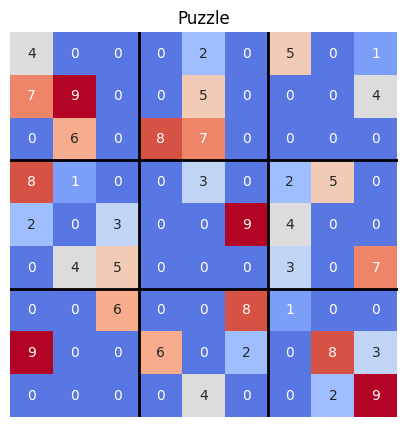

Correct
438926571792153864561874932819437256273569418645281397326798145954612783187345629
Execution time of solve(): 0.0007 seconds


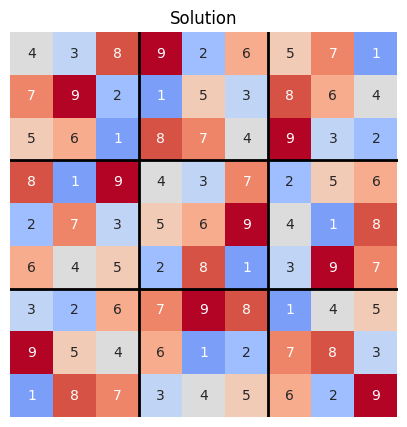

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import time # Import the time module

def draw_sudoku(sdk, title = 'Soluion'):
  fig = plt.figure(figsize=(5, 5))
  ax = sns.heatmap(sdk.cells, annot= True, cmap='coolwarm', cbar=False, xticklabels=False, yticklabels=False, vmin = -1, vmax = 9)
  # Add lines to delineate 3x3 blocks
  for i in range(1, 3):
      ax.axhline(3 * i, color='black', linewidth=2)
      ax.axvline(3 * i, color='black', linewidth=2)
  plt.title(title)
  plt.show()
  return fig

puzzle_fig = draw_sudoku(sdk, 'Puzzle')
puzzle_fig.savefig('sudoku_puzzle.pdf')

start_time = time.time() # Record start time
sdk.solve()
end_time = time.time() # Record end time

print(f"Execution time of solve(): {end_time - start_time:.4f} seconds") # Print execution time
solution_fig = draw_sudoku(sdk, 'Solution')
solution_fig.savefig('sudoku_solution.pdf')

In [8]:
'''
from google.colab import drive
drive.mount('/content/drive', force_remount = True)
input_path = '/content/drive/My Drive/Colab Notebooks/Recursion Book/CH03 Sudoku/examples/'
debug = True
if (debug):
  !ls "$input_path"
input_file = input_path + '17hints.csv'
dim = 1
sdk = Sudoku(input_file, dim, debug)
'''

'\nfrom google.colab import drive\ndrive.mount(\'/content/drive\', force_remount = True)\ninput_path = \'/content/drive/My Drive/Colab Notebooks/Recursion Book/CH03 Sudoku/examples/\'\ndebug = True\nif (debug):\n  !ls "$input_path"\ninput_file = input_path + \'17hints.csv\'\ndim = 1\nsdk = Sudoku(input_file, dim, debug)\n'